In [1]:
import pandas as pd
import numpy as np

In [2]:
 df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [6]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
#columns_to_scale = ['Annual Income (k$)', 'Age', 'Spending Score(1-100)']
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

scaler = StandardScaler()

#df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])
features = ['Gender','Age','Annual Income (k$)','Spending Score (1-100)']

X = scaler.fit_transform(df[features])

In [12]:
print(X)

[[-1.12815215 -1.42456879 -1.73899919 -0.43480148]
 [-1.12815215 -1.28103541 -1.73899919  1.19570407]
 [ 0.88640526 -1.3528021  -1.70082976 -1.71591298]
 [ 0.88640526 -1.13750203 -1.70082976  1.04041783]
 [ 0.88640526 -0.56336851 -1.66266033 -0.39597992]
 [ 0.88640526 -1.20926872 -1.66266033  1.00159627]
 [ 0.88640526 -0.27630176 -1.62449091 -1.71591298]
 [ 0.88640526 -1.13750203 -1.62449091  1.70038436]
 [-1.12815215  1.80493225 -1.58632148 -1.83237767]
 [ 0.88640526 -0.6351352  -1.58632148  0.84631002]
 [-1.12815215  2.02023231 -1.58632148 -1.4053405 ]
 [ 0.88640526 -0.27630176 -1.58632148  1.89449216]
 [ 0.88640526  1.37433211 -1.54815205 -1.36651894]
 [ 0.88640526 -1.06573534 -1.54815205  1.04041783]
 [-1.12815215 -0.13276838 -1.54815205 -1.44416206]
 [-1.12815215 -1.20926872 -1.54815205  1.11806095]
 [ 0.88640526 -0.27630176 -1.50998262 -0.59008772]
 [-1.12815215 -1.3528021  -1.50998262  0.61338066]
 [-1.12815215  0.94373197 -1.43364376 -0.82301709]
 [ 0.88640526 -0.27630176 -1.43

In [13]:
from sklearn.cluster import KMeans

In [14]:
wcss = []

for i in range(1,11):
    
    kmeans = KMeans(
        n_clusters=i, 
        init='k-means++',
        n_init=10,
        random_state=0
    )
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

In [15]:
wcss

[800.0000000000002,
 588.8026767824936,
 476.78755441351586,
 386.82842558376666,
 325.0949800888802,
 275.030671001447,
 239.32786167263316,
 199.75046112065567,
 176.41909572933417,
 152.02983429775685]

In [16]:
import matplotlib.pyplot as plt

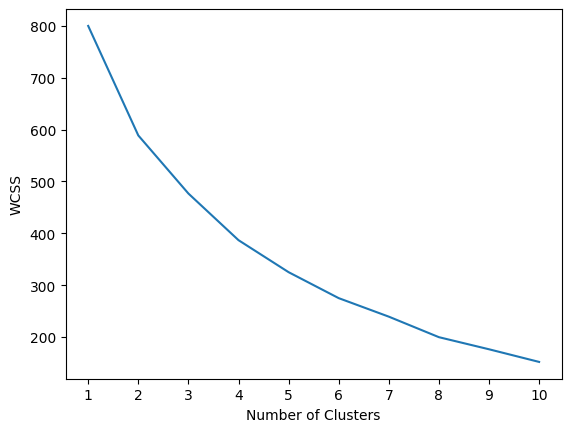

In [17]:
plt.plot(range(1, 11),wcss)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [24]:
kmeans = KMeans(n_clusters = 5, init = "k-means++")

In [25]:
X = df[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']]
labels = kmeans.fit_predict(X)

In [26]:
labels

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3,
       2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 2, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1], dtype=int32)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


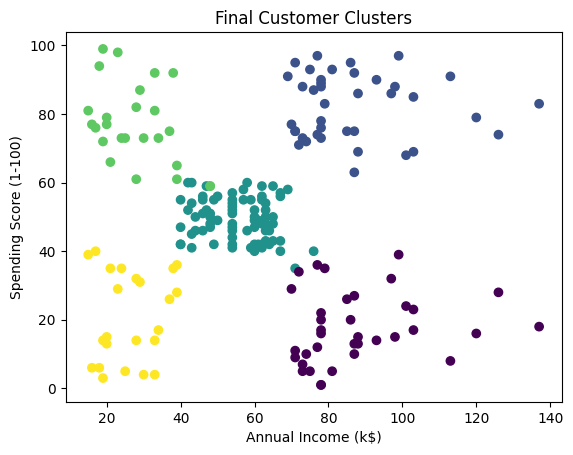

In [28]:
import matplotlib.pyplot as plt

plt.scatter(
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=labels
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Final Customer Clusters")

plt.show()

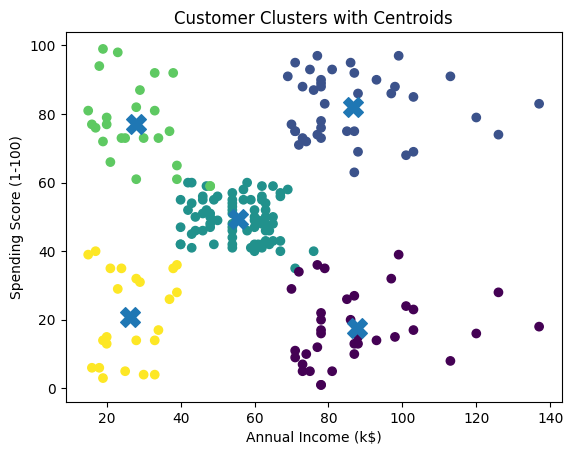

In [29]:
centroids = kmeans.cluster_centers_

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=labels)

plt.scatter(
    centroids[:,2], 
    centroids[:,3], 
    s=200, 
    marker='X'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters with Centroids")

plt.show()

In [30]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, kmeans.labels_)
print(score)

0.4402372958247734


In [32]:
from sklearn.metrics import calinski_harabasz_score

score = calinski_harabasz_score(X, kmeans.labels_)
print(score)

150.60531842772454
